In [1]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
# dt = ds.Coco("/home/wanderer2414/coco2017/")
from dataset2 import YOLODataset, test
import config
from torch import tensor, arange, float as tfloat
import matplotlib.pyplot as plt
import matplotlib.patches as pat
dt = ds.Coco("/home/wanderer2414/COCO")
# i = 1
# ar = dt.getTrainTensor(0)
# boxes = dt.getTrainLabel(0)
# print(boxes.shape)
# for box in boxes:
#     x1,y1,x2,y2,cls = box.detach().numpy()
#     # print(x,y,w,h,cls, config.COCO_LABELS[cls.astype(int)])
#     # x = (x-w/2)*W
#     # w = w*W
#     # y = (y-h/2)*H
#     # h = h*H
#     rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='red')
#     plt.subplot().add_patch(rect)
# # ar = ar.permute(2, 0, 1).unsqueeze(0)/255
# img = TensorToImg(ar)
# plt.imshow(img)
# label = boxes
# H, W = ar.shape[-2:]
# X1 = label[:, 0].floor().long()
# X2 = label[:, 2].ceil().long()
# Y1 = label[:, 1].floor().long()
# Y2 = label[:, 3].ceil().long()
# C_gt = label.shape[0]
# row = arange(H, device=label.device, dtype=tfloat).view(1,1,H,1).expand(1,C_gt,H,W)
# col = arange(W, device=label.device, dtype=tfloat).view(1,1,1,W).expand(1,C_gt,H,W)
# center_x = ((X1+X2)/2).view(1, -1, 1, 1).expand(1, C_gt, H, W)
# center_y = ((Y1+Y2)/2).view(1, -1, 1, 1).expand(1, C_gt, H, W)
# distance = ((col-center_x).square() + (row-center_y).square()).sqrt()
# target = distance.min(dim=1, keepdim=True).values
# target = 1-target/target.max()
# print(target.shape)
# target = target.repeat(1, 3, 1, 1)
# img = TensorToImg(target)
# plt.imshow(img)


/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()
/home/wanderer2414/MyRCNN/config.py:65: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/wanderer2414/MyRCNN/config.py:75: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRot

In [2]:
# import MyRCNN
# import torch
# dev = "cpu"
# model = MyRCNN.Model(device=torch.device(dev))
# model.model.load_state_dict(torch.load("bbx.pth", map_location=dev))
def count_parameters(model):
        return sum(p.numel() for p in model.parameters())

# print(count_parameters(model.model.color))

In [ ]:
import MyRCNN
import torch
model = MyRCNN.Model(device=torch.device("cuda"))
print(count_parameters(model.model))
# for module in model.model.color.prepare.modules():
#     print(module)
model.train(dt)

893
[09:28:54] 0.6796729564666748                                                                        235      /   117265

In [ ]:

from torch import stack
import torch
from torch import Tensor
def nms(boxes: Tensor)->Tensor:
    N = boxes.shape[0]
    rows, cols = torch.meshgrid(torch.arange(N, device=boxes.device), torch.arange(N, device=boxes.device), indexing='ij')
    
    boxes1 = boxes.unsqueeze(1).expand(N, N, 4)
    boxes2 = boxes.unsqueeze(0).expand(N, N, 4)
    x1 = torch.max(boxes1[:, :, 0], boxes2[:, :, 0])
    x2 = torch.min(boxes1[:, :, 2], boxes2[:, :, 2])
    w = x2 - x1
    del x1, x2
    y1 = torch.max(boxes1[:, :, 1], boxes2[:, :, 1])
    y2 = torch.min(boxes1[:, :, 3], boxes2[:, :, 3])
    h = y2-y1
    del y2, y1
    s = ((boxes[:, 2]-boxes[:, 0])*(boxes[:, 3] - boxes[:, 1]))
    s = s.unsqueeze(1).expand(N, N) + s.unsqueeze(0).expand(N, N)
    intersect = w*h
    IoU = intersect/(s - intersect)
    IoU = IoU * (rows>cols)
    cond = IoU > 0.9
    indices = (cond.any(dim=1).logical_not())
    
    return boxes[indices]

def mode_pool2d(x, kernel_size=3, stride=1, padding=0) -> Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.view(B, C, kernel_size * kernel_size, -1)
    median = patches.mode(dim=2).values
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return median.view(B, C, H_out, W_out)
import gc
gc.collect()

76

torch.Size([1, 136, 5])
torch.Size([4, 4])
8.0 -85.0 402.0 125.0
107.0 -41.0 275.0 145.0
89.0 -34.0 289.0 140.0
115.0 58.0 393.0 430.0


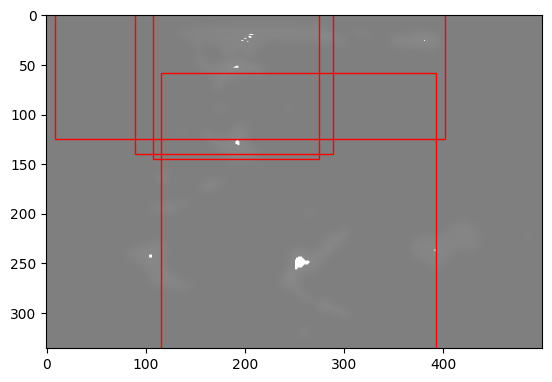

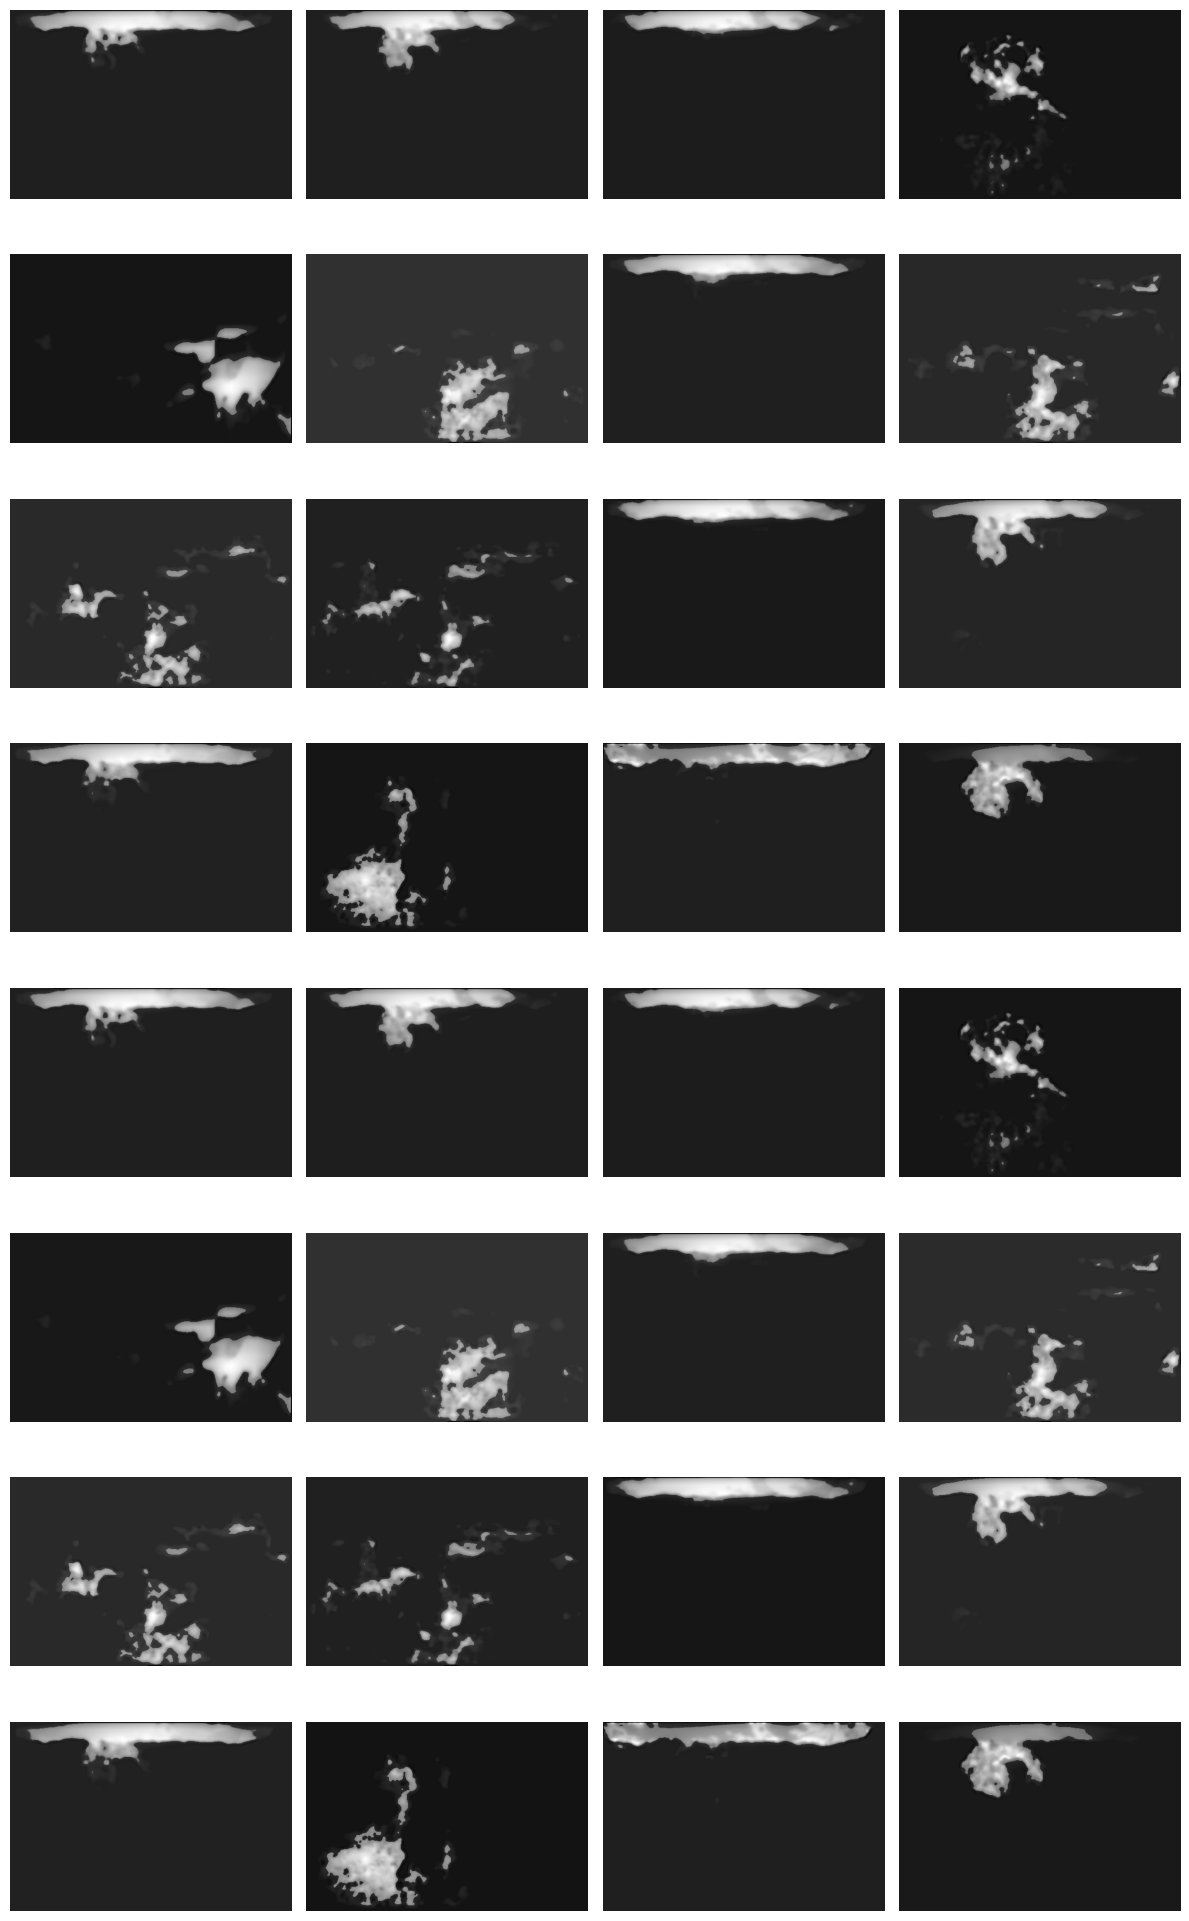

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from dataset import TensorToImg, ImgToTensor
x = dt.getTrainTensor(2).to(device=torch.device("cuda"))
# x = x[:, :, 0:350, 250:600]
mask, color, result = model.model(x)
boxes = result[1][:, :, 1:].squeeze(0)
print(result[1].shape)
boxes = nms(boxes)
print(boxes.shape)
x = (x*255/16).round()*16/256
x = mode_pool2d(x, 11, 1, 5)
prep = model.model.color.prepare(x)
score = model.model.feat.bbx.score[:-2](color)
x = result[0]
x = x.repeat(1, 3, 1, 1)
for box in boxes:
    x1, y1, x2, y2 = box.detach().cpu().numpy()
    print(x1, y1, x2, y2)
    rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='red')
    plt.subplot().add_patch(rect)
plt.imshow(TensorToImg(x.detach().cpu()))
fig, axes = plt.subplots(color.shape[1]//4, 4, figsize=(12, 20))
for i, ax in enumerate(axes.flat):
    x = color[:, i:i+1, :, :]
    x = x.repeat(1, 3, 1, 1)
    x = x-x.min()
    x = x/x.max()
# ImgWrite("test.png", TensorToImg(x.detach().cpu()))
    ax.imshow(TensorToImg(x.detach().cpu()))
    ax.axis('off')  # Hide axes
plt.tight_layout()
plt.show()
